<a href="https://colab.research.google.com/github/AcSsalazar/the-color-of-emotions/blob/main/Notebooks/4.4-training-building-a-cnn-mfccs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Implementación de Unidad Recurrente Bidireccional con Compuerta (BiGRU) Para Tensores Basados en MFCC.

En este notebook vamos a levar a cabo el uso de una *Bidirectional gated recurrent Unit* por sus siglas en ingles *BiGRU*, es una variante avanzada de las Redes Neuronales Recurrentes (RNN) que mejora el procesamiento de secuencias al analizar los datos en ambas direcciones: de principio a fin (hacia adelante) y de fin a principio (hacia atrás). Esta arquitectura combina dos capas de Unidades Recurrentes con Compuerta (GRU) independientes para capturar el contexto tanto pasado como futuro de cada elemento en una secuencia. Para sacar provecho de los canales que conservan la dimension temporal en nuestros tensores, es decir los canales correspondientes al delta del mel-spec y a espectrograma *cohclear db*.

Cabe destacar que, para las primeros bloques de la arquitectura de la Red Neuronal, se usan unidades estandar del tipo Convolusional, de manera que, nuestra arquitectura posee la siguiente estructura base:

## Monitoreo con Weights & Biases

Para optimizar el rendimiento de nuestra arquitectura CBGRU (CNN + BiGRU), integramos Weights & Biases (W&B) como plataforma central de experimentación. En modelos híbridos complejos, es crítico entender cómo interactúan las capas convolucionales y las recurrentes.

**Seguimiento (Tracking)**: Registro en tiempo real de métricas (pérdida, precisión), hiperparámetros y consumo de hardware (GPU/CPU).

**Visualización**: Tableros interactivos para comparar ejecuciones y analizar el rendimiento del modelo.

**Artefactos**: Control de versiones para datasets y modelos, garantizando la trazabilidad y reproducibilidad.

**Barrido (Sweeps)**: Automatización de la búsqueda de los mejores hiperparámetros para optimizar el modelo.

El objetivo es:

* Registrar cada ejecución (hiperparámetros + métricas + artefactos)

* Seleccionar el mejor punto de control usando solo la validación.

* Evaluar una sola vez al final para evitar la fuga de datos de las pruebas.

* Constatar la evolución de los modelos y sus diferentes arquitecturas.

* Obener un modelo final para su inferencia y despliegue a partir de la verificación de su rendimiento despúes de la respectiva experimentación.


### 1.0 Imports y configuración base


In [1]:
# Imports
#------------------------------------------------------------------------------------------
import os
import copy
import numpy as np
import torch
import xgboost as xgb
import random as random
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd
import time
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torchaudio import transforms as T
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay,f1_score, accuracy_score)
from google.colab import drive
from tqdm import tqdm
from collections import Counter

In [2]:
# ─── Instalación de Weights & Biases ────────────────────────────────
# Descomenta las líneas siguientes si wandb no está instalado en tu entorno:
!pip install wandb -q

# Para autenticarte (solo la primera vez por sesión de Colab):
import wandb; wandb.login()

# USE_WANDB se define en la celda de configuración más abajo.
# Déjalo en False para ejecutar sin tracking remoto.

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: acsalazar (acsalazar-numbral) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [3]:
# Semilla y runtime
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


### 1.2 Carga de tensores desde Drive (train/val/test)

Los archivos `.pt` generados en el notebook 3.2 contienen un diccionario con `x`, `y`,
metadatos y el mapeo de clases. Ajusta `BASE_DIR_TENSOR` según tu ruta local/Drive.


In [4]:
drive.mount('/content/drive')
! cp -r /content/drive/MyDrive/split_pytorch_tensors_mfcc /content/split_pytorch_tensors

Mounted at /content/drive


In [19]:
BASE_DIR_TENSOR = '/content/split_pytorch_tensors'
BATCH_SIZE = 32

SPLIT_FILES = {
    'train': 'train_tensors.pt',
    'val': 'val_tensors.pt',
    'test': 'test_tensors.pt',
}

def load_pack(split_name: str):
    path = os.path.join(BASE_DIR_TENSOR, SPLIT_FILES[split_name])
    if not os.path.exists(path):
        raise FileNotFoundError(f'No existe el archivo: {path}')
    return torch.load(path, map_location='cpu', weights_only=False)

# Cargamos lo packs en variables aun no son tensores puros
train_pack = load_pack('train')
val_pack = load_pack('val')
test_pack = load_pack('test')

# Verificamos las clases del diccionario dentro del pack
class_to_idx = train_pack['class_to_idx']
idx_to_class = {v: k for k, v in class_to_idx.items()}
class_names = [idx_to_class[i] for i in sorted(idx_to_class.keys())]
print('Clases:', class_names)
print('Shape train:', tuple(train_pack['x'].shape))

Clases: ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Shape train: (7422, 3, 13, 51)


### 1.3 Estrategia de normalización y augmentation

**Normalización:**  
Los tensores provienen del notebook `3.2` y ya fueron normalizados con **z-score por muestra y canal** (`zscore_per_channel`). No se aplica una segunda normalización a nivel de dataset para evitar doble normalización.

**Augmentation online (desactivado por defecto):**  
El notebook `3.2` ya añadió muestras extra de `surprised` con **ruido** y **shift temporal** durante la exportación (augmentación *offline*). Por eso `augment=False` es el valor por defecto en `build_dataloaders`: la augmentación offline ya aporta robustez sin el riesgo de distorsionar demasiado las entradas.  
Si se desea augmentación online adicional, se puede activar `augment=True`; en ese caso se aplica exclusivamente **SpecAugment** (FrequencyMasking + TimeMasking), más un pequeño ruido gaussiano opcional.

**Early stopping y scheduler:**  
Se usa **macro-F1** como criterio en lugar de `val_loss`, ya que es más informativo para datasets desbalanceados y refleja mejor el objetivo de clasificación equitativa entre clases.


In [15]:
class TensorPackDataset(Dataset):
  def __init__(self, pack, augment=False):
      self.x = pack['x'].float() # [N, 3, n_mfcc, targetframes]
      self.y = pack['y'].long()  # len(N)
      self.augment = augment

      # Definimos las transformaciones de SpecAugment
      # Ajustar n_freq_masks y n_time_masks según el tamaño (13x51)
      if augment:
          self.spec_aug = nn.Sequential(
              T.FrequencyMasking(freq_mask_param=3), # Enmascara hasta 4 bins de mel
              T.TimeMasking(time_mask_param=1)       # Enmascara hasta 2 frames de tiempo
          )

  def __len__(self):
      return self.y.shape[0]

  def __getitem__(self, idx):
      x = self.x[idx]
      y = self.y[idx]

      if self.augment:
          # SpecAugment espera [batch, channel, freq, time] o [channel, freq, time]
          # Aplicamos la misma máscara a los 3 canales (MFCC, Delta, Delta2)
          x = self.spec_aug(x)
          '''
          # Opcional: Pequeño ruido gaussiano
          if random.random() < 0.5:
              x = x + 0.01 * torch.randn_like(x)'''

      return x, y

### 1.4 Configuracion Early Stop

In [20]:
class EarlyStopping:
    """Early stopping configurable para minimizar (val_loss) o maximizar (val_f1)."""
    def __init__(self, patience=5, min_delta=0.0, mode="min"):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode  # "min" para loss, "max" para F1
        self.best = None
        self.counter = 0

    def step(self, metric):
        """Devuelve True cuando se debe detener el entrenamiento."""
        if self.best is None:
            self.best = metric
            return False
        improved = (metric > self.best + self.min_delta) if self.mode == "max" \
                   else (metric < self.best - self.min_delta)
        if improved:
            self.best = metric
            self.counter = 0
            return False
        self.counter += 1
        print(f"Early Stopping: {self.counter}/{self.patience} (best={self.best:.4f})")
        return self.counter >= self.patience


### 1.5 Dataloaders

In [17]:
# Solo aumentamos el set de TRAIN. Val y Test deben quedar puros.
def build_dataloaders(batch_size=BATCH_SIZE):
    pin = torch.cuda.is_available()
    # Valor por defecto: augment= False
    train_ds = TensorPackDataset(train_pack, augment=False)
    val_ds = TensorPackDataset(val_pack, augment=False)
    test_ds = TensorPackDataset(test_pack, augment=False)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=pin)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=pin)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=pin)

    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = build_dataloaders()


### 1.6 Definición de la CGRU


In [21]:
class EmotionCGRU(nn.Module):
    def __init__(self, num_classes, classifier_dropout=0.5):
        super().__init__()

        # Entrada esperada: (Batch, 3, 13, 51)
        self.cnn = nn.Sequential(
            # Bloque Convolucional 1
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            # Reducimos frecuencia suavemente, mantenemos tiempo intacto
            nn.MaxPool2d(kernel_size=(2, 1)), # Frec: 13 -> 6, Tiempo: 51 -> 51

            # Bloque Convolucional 2
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 1)), # Frec: 6 -> 3, Tiempo: 51 -> 51
            nn.Dropout2d(0.3),

            # Bloque Convolucional 3
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(0.3)
            # Salida de CNN: (Batch, 64, 3, 51)
        )

        # 64 canales * 3 bins de frecuencia restantes = 192 features por frame
        self.gru_input_size = 64 * 3

        self.bigru = nn.GRU(
            input_size=self.gru_input_size,
            hidden_size=64,
            num_layers=2,
            bidirectional=True,
            batch_first=True,
            dropout=0.25
        )

        self.classifier = nn.Sequential(
            # 64 * 2 porque la GRU es bidireccional
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(classifier_dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # 1. Extracción de características CNN
        x = self.cnn(x)

        batch_size, channels, freq, time = x.size()

        # 2. Formatear para GRU: (Batch, Tiempo, Features)
        # Permutamos a (Batch, Tiempo, Canales, Frecuencia) -> (Batch, 51, 64, 3)
        x = x.permute(0, 3, 1, 2).contiguous()
        # Aplanamos a (Batch, 51, 192)
        x = x.view(batch_size, time, channels * freq)

        # 3. Modelado Secuencial
        gru_out, _ = self.bigru(x)

        # 4. Pooling temporal (promedio) y clasificación
        x = gru_out.mean(dim=1)
        return self.classifier(x)

## Tracking con Weights & Biases (W&B)

En los cuadernos de Colab/Jupyter, volver a ejecutar las celdas a menudo sobrescribe variables y resultados, lo que facilita la pérdida de:

* Qué hiperparámetros produjeron el mejor modelo y
las curvas de entrenamiento completas (pérdida/F1 vs. época).

* El mejor punto de control para esa ejecución, la matriz de confusión y
informe de clasificación asociado a ese punto de control.

***W&B*** soluciona esto almacenando las ejecuciones en un registro de experimentos externo, donde cada ejecución incluye:

1. Aspectos de la configuración `(wandb.config)` como por ejemplo: `dropout`,`seeds`,`weight decay`,`Learnig rate`, etc.

2. La serie temporal de métricas por época `train val loss`, `macro-F1`, `LR`.

3. Artefactos como puntos de control del modelo e informes.

### 2.0 Configuración de W&B

El baseline se contruye a partir de experimentacion anterior donde se obtuvo mayor estabilidad con un `BATCH_SIZE=32`, y como mencionamos antes sin *online data augmentation*, aunque se conservan estas funcionalidades con motivos investigativos, para futuros usuarios.

In [22]:
# --- Configuración de W&B y matriz de experimentos -----------------------------

# Establece USE_WANDB = True para registrar experimentos en Weights & Biases.
# Requiere wandb instalado (!pip install wandb -q) y autenticado con API key.
USE_WANDB      = True                # ← cambiar a True para activar tracking
WANDB_PROJECT  = "tcoe-experiments-no-aug-mfccs"
WANDB_GROUP    = "cnn-cgru-batch32-2.2"  # agrupa los cuatro experimentos en la misma vista (Mul útil)

# --- Hiperparámetros que son fijos en los cuatro experimentos-------------------

# Baseline confirmado: BATCH_SIZE=32, augment=False (sin SpecAugment online),

EPOCHS              = 50
LABEL_SMOOTHING     = 0.05
MAX_GRAD_NORM       = 1.0
EARLY_STOP_PATIENCE = 8    # patience mayor para que los drops de LR tomen efecto, no usar un valor menor a 4

# Directorio local para guardar los mejores checkpoints por ejecucion
CHECKPOINT_DIR = '/content/checkpoints_cnn'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# --- Matriz de experimentos (4 ejecuciones) ------------------------------------
# Scheduler fijo: ReduceLROnPlateau(mode='max', factor=0.5, patience=2) sobre val macro-F1.
# Gradient clipping: max_norm=1.0.  Label smoothing: 0.05.

RUN_MATRIX = [
    # Run 1 — baseline fuerte: LR conservador, dropout estándar, pesos de clase
    {
        "run_name": "run1_lr3e4_wd1e3_do05_cw",
        "lr": 3e-4, "weight_decay": 1e-3,
        "classifier_dropout": 0.5,
        "use_class_weights": True,
    },
    # Run 2 — LR más alto: explorar convergencia más rápida
    {
        "run_name": "run2_lr5e4_wd1e3_do05_cw",
        "lr": 5e-4, "weight_decay": 1e-3,
        "classifier_dropout": 0.5,
        "use_class_weights": True,
    },
    # Run 3 — dropout reducido: menos regularización en el clasificador
    {
        "run_name": "run3_lr3e4_wd1e3_do03_cw",
        "lr": 3e-4, "weight_decay": 1e-3,
        "classifier_dropout": 0.3,
        "use_class_weights": True,
    },
    # Run 4 — diagnóstico: sin pesos de clase (mide impacto del balanceo)
    {
        "run_name": "run4_lr3e4_wd1e3_do05_nocw",
        "lr": 3e-4, "weight_decay": 1e-3,
        "classifier_dropout": 0.5,
        "use_class_weights": False,
    },
]


### 4. Entrenamiento y validación


In [23]:
# TRAIN
#-------------------------------------------------------------------------------
# Calcular pesos de clase: total / (n_clases * counts)
# Esto da más peso a las clases con menos muestras.
''''surprised' tiene muestras extra desde la exportación offline, por lo que su peso
    resultante será menor que otras clases sub-representadas.'''

y_train_cpu = train_pack['y'].numpy()
label_counts = Counter(y_train_cpu)
total_samples = len(y_train_cpu)
num_classes = len(class_names)

class_weights = []
for i in range(num_classes):
    count = label_counts.get(i, 1)
    weight = total_samples / (num_classes * count)
    class_weights.append(weight)

class_weights_tensor = torch.FloatTensor(class_weights).to(device)
print(f"Pesos calculados para CrossEntropyLoss: {class_weights}")


def train_one_epoch(model, loader, criterion, optimizer, device, epoch=None, max_grad_norm=1.0):
    model.train()
    running_loss = 0.0
    running_correct = 0

    pbar = tqdm(loader, desc=f"Epoch {epoch:02d} [train]", leave=False)
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        # Gradient clipping para estabilizar el entrenamiento del GRU
        if max_grad_norm is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_correct += (outputs.argmax(1) == labels).sum().item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = running_correct / len(loader.dataset)
    return epoch_loss, epoch_acc


# VAL
#-------------------------------------------------------------------------------
@torch.no_grad()
def evaluate(model, loader, criterion, device, epoch=None):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    all_preds, all_targets = [], []

    pbar = tqdm(loader, desc=f"Epoch {epoch:02d} [val]", leave=False)
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * inputs.size(0)
        running_correct += (outputs.argmax(1) == labels).sum().item()
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_targets.extend(labels.cpu().numpy())
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = running_correct / len(loader.dataset)
    # Macro-F1: métrica clave para datasets desbalanceados con objetivo de clasificación equitativa
    epoch_f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    return epoch_loss, epoch_acc, epoch_f1


# TEST / PREDICCIONES
#-------------------------------------------------------------------------------
@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()
    all_preds, all_targets = [], []
    for inputs, labels in loader:
        outputs = model(inputs.to(device))
        all_preds.append(outputs.argmax(1).cpu().numpy())
        all_targets.append(labels.numpy())
    return np.concatenate(all_targets), np.concatenate(all_preds)


Pesos calculados para CrossEntropyLoss: [0.896268566598237, 0.896268566598237, 0.896268566598237, 0.896268566598237, 0.9647731704146627, 0.896268566598237, 2.5987394957983194]



  INICIANDO: run1_lr3e4_wd1e3_do05_cw
  lr=0.0003  wd=0.001  dropout=0.5  class_weights=True



[22:04:17] Epoca 01/50 | Train loss 1.9238 acc 0.2136 | Val loss 1.7365 acc 0.3373 f1 0.2910 | lr 3.0e-04 | Time 2.6s


[22:04:19] Epoca 02/50 | Train loss 1.7381 acc 0.2961 | Val loss 1.7071 acc 0.3517 f1 0.3041 | lr 3.0e-04 | Time 2.5s


[22:04:22] Epoca 03/50 | Train loss 1.6703 acc 0.3348 | Val loss 1.6472 acc 0.3720 f1 0.3292 | lr 3.0e-04 | Time 2.4s


[22:04:24] Epoca 04/50 | Train loss 1.6170 acc 0.3556 | Val loss 1.5908 acc 0.3935 f1 0.3433 | lr 3.0e-04 | Time 2.8s


...

[22:04:54] Epoca 15/50 | Train loss 1.4063 acc 0.4524 | Val loss 1.5161 acc 0.4354 f1 0.3927 | lr 7.5e-05 | Time 2.6s
Early Stopping: 4/8 (best=0.4111)


[22:04:57] Epoca 16/50 | Train loss 1.3926 acc 0.4600 | Val loss 1.5302 acc 0.4390 f1 0.3964 | lr 7.5e-05 | Time 3.0s
Early Stopping: 5/8 (best=0.4111)


[22:05:01] Epoca 17/50 | Train loss 1.3826 acc 0.4710 | Val loss 1.5245 acc 0.4342 f1 0.3913 | lr 3.7e-05 | Time 3.9s
Early Stopping: 6/8 (best=0.4111)


[22:05:03] Epoca 18/50 | Train loss 1.3857 acc 0.4709 | Val loss 1.5416 acc 0.4282 f1 0.3867 | lr 3.7e-05 | Time 2.5s
Early Stopping: 7/8 (best=0.4111)


[22:05:06] Epoca 19/50 | Train loss 1.3840 acc 0.4698 | Val loss 1.5137 acc 0.4474 f1 0.4106 | lr 3.7e-05 | Time 2.5s
Early Stopping: 8/8 (best=0.4111)
Early stopping en epoch 19 (best val_f1=0.4111)

--- RESULTADO TEST [run1_lr3e4_wd1e3_do05_cw] ---
  best_epoch=11  best_val_f1=0.4111
  test_macro_f1=0.4557  test_acc=0.4810
              precision    recall  f1-score   support

       angry       0.54      0.85      0.66       144
     disgust       0.34      0.13      0.19       144
     fearful       0.49      0.20      0.29       144
       happy       0.32      0.38      0.35       144
     neutral       0.54      0.71      0.61       144
         sad       0.58      0.56      0.57       144
   surprised       0.41      0.72      0.52        32

    accuracy                           0.48       896
   macro avg       0.46      0.51      0.46       896
weighted avg       0.47      0.48      0.45       896



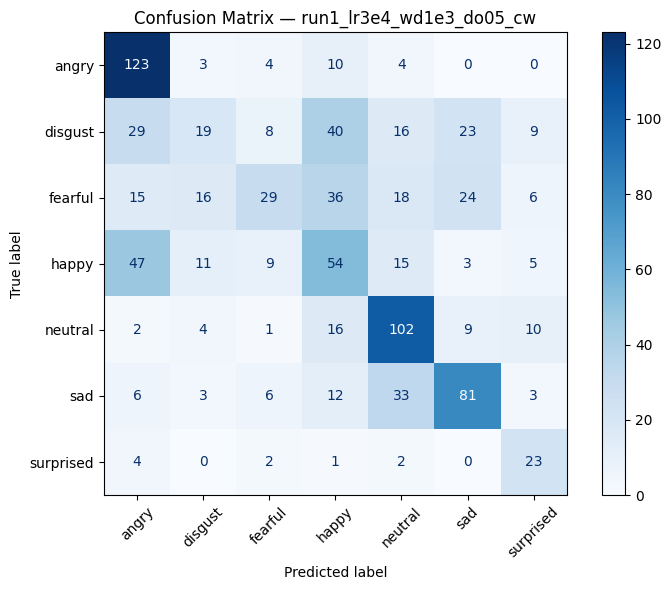

lr,████████▄▄▄▄▄▂▂▂▁▁▁
test_acc,▁
test_macro_f1,▁
train_acc,▁▃▄▅▆▆▆▆▇▇▇▇█▇▇████
train_loss,█▆▅▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁
val_acc,▁▂▃▄▅▆▆▇▅▆█▅█▇▇▇▇▇█
val_loss,█▇▅▃▃▃▃▃▄▂▁▃▁▂▁▂▁▂▁
val_macro_f1,▁▂▃▄▄▆▆▆▆▆█▅█▇▇▇▇▇█
lr,4e-05
test_acc,0.48103
test_macro_f1,0.45565



  INICIANDO: run2_lr5e4_wd1e3_do05_cw
  lr=0.0005  wd=0.001  dropout=0.5  class_weights=True



[22:05:13] Epoca 01/50 | Train loss 1.8639 acc 0.2449 | Val loss 1.6989 acc 0.3696 f1 0.3235 | lr 5.0e-04 | Time 3.1s


[22:05:17] Epoca 02/50 | Train loss 1.6754 acc 0.3297 | Val loss 1.6330 acc 0.3636 f1 0.3261 | lr 5.0e-04 | Time 4.2s


[22:05:20] Epoca 03/50 | Train loss 1.6023 acc 0.3583 | Val loss 1.6432 acc 0.3720 f1 0.3333 | lr 5.0e-04 | Time 2.9s


...

[22:06:17] Epoca 23/50 | Train loss 1.2763 acc 0.5241 | Val loss 1.4510 acc 0.4665 f1 0.4508 | lr 3.1e-05 | Time 3.1s
Early Stopping: 4/8 (best=0.4701)


[22:06:21] Epoca 24/50 | Train loss 1.2757 acc 0.5216 | Val loss 1.4408 acc 0.4701 f1 0.4575 | lr 3.1e-05 | Time 3.2s
Early Stopping: 5/8 (best=0.4701)


[22:06:23] Epoca 25/50 | Train loss 1.2796 acc 0.5279 | Val loss 1.4575 acc 0.4701 f1 0.4529 | lr 1.6e-05 | Time 2.8s
Early Stopping: 6/8 (best=0.4701)


[22:06:26] Epoca 26/50 | Train loss 1.2785 acc 0.5247 | Val loss 1.4464 acc 0.4773 f1 0.4653 | lr 1.6e-05 | Time 2.6s
Early Stopping: 7/8 (best=0.4701)


[22:06:29] Epoca 27/50 | Train loss 1.2852 acc 0.5201 | Val loss 1.4579 acc 0.4653 f1 0.4484 | lr 1.6e-05 | Time 2.6s
Early Stopping: 8/8 (best=0.4701)
Early stopping en epoch 27 (best val_f1=0.4701)

--- RESULTADO TEST [run2_lr5e4_wd1e3_do05_cw] ---
  best_epoch=19  best_val_f1=0.4701
  test_macro_f1=0.4941  test_acc=0.5100
              precision    recall  f1-score   support

       angry       0.60      0.78      0.68       144
     disgust       0.40      0.32      0.36       144
     fearful       0.43      0.25      0.32       144
       happy       0.43      0.43      0.43       144
     neutral       0.53      0.76      0.62       144
         sad       0.61      0.51      0.56       144
   surprised       0.47      0.53      0.50        32

    accuracy                           0.51       896
   macro avg       0.50      0.51      0.49       896
weighted avg       0.50      0.51      0.49       896



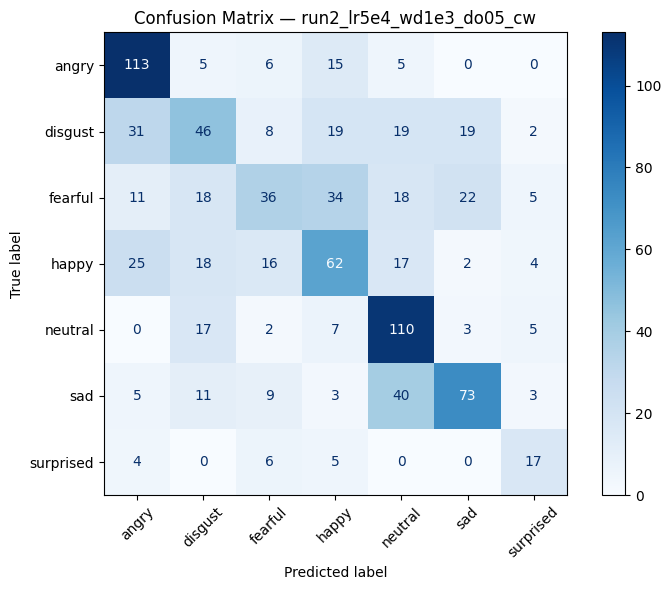

lr,████████▄▄▄▄▄▃▃▃▃▂▂▂▂▁▁▁▁▁▁
test_acc,▁
test_macro_f1,▁
train_acc,▁▃▄▅▅▅▅▆▆▆▇▇▇▇▇▇▇██████████
train_loss,█▆▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▁▂▃▄▅▄▅▄▆▇▆▇▇▇▇▇▇█▇▆▇▇▇▇█▇
val_loss,█▆▆▅▄▅▅▄▄▂▂▃▁▂▁▂▂▁▁▂▂▂▁▁▁▁▁
val_macro_f1,▁▁▁▂▄▄▃▄▄▅▇▆▇▇▇▆▆▇█▇▆▇▇▇▇█▇
lr,2e-05
test_acc,0.51004
test_macro_f1,0.49407



  INICIANDO: run3_lr3e4_wd1e3_do03_cw
  lr=0.0003  wd=0.001  dropout=0.3  class_weights=True



[22:06:37] Epoca 01/50 | Train loss 1.8704 acc 0.2342 | Val loss 1.7200 acc 0.3517 f1 0.3066 | lr 3.0e-04 | Time 3.4s


[22:06:40] Epoca 02/50 | Train loss 1.7003 acc 0.3157 | Val loss 1.6611 acc 0.3565 f1 0.3124 | lr 3.0e-04 | Time 2.8s


[22:06:42] Epoca 03/50 | Train loss 1.6359 acc 0.3490 | Val loss 1.6392 acc 0.3816 f1 0.3421 | lr 3.0e-04 | Time 2.8s


...

[22:08:30] Epoca 39/50 | Train loss 1.1702 acc 0.5759 | Val loss 1.4671 acc 0.4940 f1 0.4778 | lr 3.7e-05 | Time 2.8s
Early Stopping: 4/8 (best=0.4879)


[22:08:34] Epoca 40/50 | Train loss 1.1645 acc 0.5839 | Val loss 1.4937 acc 0.4916 f1 0.4730 | lr 3.7e-05 | Time 3.4s
Early Stopping: 5/8 (best=0.4879)


[22:08:37] Epoca 41/50 | Train loss 1.1597 acc 0.5800 | Val loss 1.4831 acc 0.4964 f1 0.4822 | lr 1.9e-05 | Time 3.4s
Early Stopping: 6/8 (best=0.4879)


[22:08:40] Epoca 42/50 | Train loss 1.1588 acc 0.5803 | Val loss 1.4780 acc 0.4880 f1 0.4720 | lr 1.9e-05 | Time 2.7s
Early Stopping: 7/8 (best=0.4879)


[22:08:43] Epoca 43/50 | Train loss 1.1556 acc 0.5818 | Val loss 1.4809 acc 0.4988 f1 0.4812 | lr 1.9e-05 | Time 2.7s
Early Stopping: 8/8 (best=0.4879)
Early stopping en epoch 43 (best val_f1=0.4879)

--- RESULTADO TEST [run3_lr3e4_wd1e3_do03_cw] ---
  best_epoch=35  best_val_f1=0.4879
  test_macro_f1=0.5431  test_acc=0.5413
              precision    recall  f1-score   support

       angry       0.57      0.81      0.67       144
     disgust       0.51      0.35      0.41       144
     fearful       0.50      0.36      0.42       144
       happy       0.42      0.43      0.42       144
     neutral       0.58      0.78      0.66       144
         sad       0.63      0.48      0.55       144
   surprised       0.65      0.69      0.67        32

    accuracy                           0.54       896
   macro avg       0.55      0.56      0.54       896
weighted avg       0.54      0.54      0.53       896



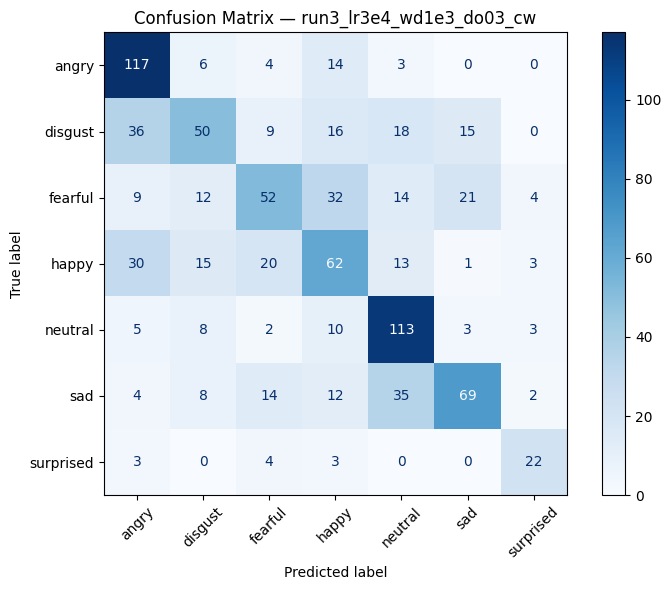

lr,███████████████████▄▄▄▄▄▄▄▄▄▄▂▂▂▂▂▂▁▁▁▁▁
test_acc,▁
test_macro_f1,▁
train_acc,▁▃▃▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇██████████
train_loss,█▆▆▅▅▅▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▁▂▃▃▄▅▄▄▅▆▅▆▆▆▅▆▆▆▆▇▆▇▇█▆█▇▇█████▇██▇██
val_loss,█▆▆▅▄▄▄▄▄▃▃▃▂▂▂▃▁▂▂▃▂▂▂▁▁▃▁▂▂▁▂▁▁▂▂▁▁▂▂▂
val_macro_f1,▁▁▂▃▂▄▄▃▄▅▆▄▆▆▆▅▆▆▆▆▆▆▇▇█▇█▇▇█████▇██▇██
lr,2e-05
test_acc,0.54129
test_macro_f1,0.54309



  INICIANDO: run4_lr3e4_wd1e3_do05_nocw
  lr=0.0003  wd=0.001  dropout=0.5  class_weights=False



[22:08:50] Epoca 01/50 | Train loss 1.9513 acc 0.2242 | Val loss 1.7363 acc 0.3457 f1 0.2764 | lr 3.0e-04 | Time 3.1s


[22:08:53] Epoca 02/50 | Train loss 1.7664 acc 0.3157 | Val loss 1.6904 acc 0.3337 f1 0.2762 | lr 3.0e-04 | Time 3.5s
Early Stopping: 1/8 (best=0.2764)


[22:08:57] Epoca 03/50 | Train loss 1.7066 acc 0.3383 | Val loss 1.6139 acc 0.3864 f1 0.3629 | lr 3.0e-04 | Time 3.3s


...

[22:10:29] Epoca 33/50 | Train loss 1.2622 acc 0.5625 | Val loss 1.4025 acc 0.4952 f1 0.4833 | lr 3.7e-05 | Time 3.6s
Early Stopping: 4/8 (best=0.4998)


[22:10:32] Epoca 34/50 | Train loss 1.2627 acc 0.5612 | Val loss 1.3921 acc 0.5060 f1 0.4984 | lr 3.7e-05 | Time 2.8s
Early Stopping: 5/8 (best=0.4998)


[22:10:34] Epoca 35/50 | Train loss 1.2454 acc 0.5666 | Val loss 1.4126 acc 0.4940 f1 0.4857 | lr 1.9e-05 | Time 2.8s
Early Stopping: 6/8 (best=0.4998)


[22:10:37] Epoca 36/50 | Train loss 1.2481 acc 0.5670 | Val loss 1.4020 acc 0.5036 f1 0.4948 | lr 1.9e-05 | Time 2.8s
Early Stopping: 7/8 (best=0.4998)


[22:10:40] Epoca 37/50 | Train loss 1.2470 acc 0.5652 | Val loss 1.3968 acc 0.5036 f1 0.4921 | lr 1.9e-05 | Time 3.2s
Early Stopping: 8/8 (best=0.4998)
Early stopping en epoch 37 (best val_f1=0.4998)

--- RESULTADO TEST [run4_lr3e4_wd1e3_do05_nocw] ---
  best_epoch=29  best_val_f1=0.4998
  test_macro_f1=0.5233  test_acc=0.5257
              precision    recall  f1-score   support

       angry       0.57      0.83      0.68       144
     disgust       0.47      0.33      0.38       144
     fearful       0.43      0.20      0.27       144
       happy       0.42      0.40      0.41       144
     neutral       0.52      0.83      0.64       144
         sad       0.62      0.55      0.58       144
   surprised       0.75      0.66      0.70        32

    accuracy                           0.53       896
   macro avg       0.54      0.54      0.52       896
weighted avg       0.51      0.53      0.50       896



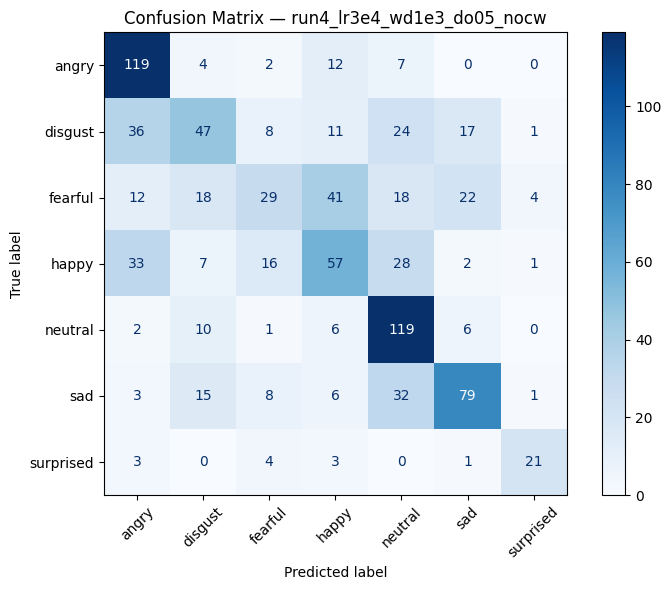

lr,██████████████████████▄▄▄▄▂▂▂▂▂▁▁▁▁▁▁
test_acc,▁
test_macro_f1,▁
train_acc,▁▃▃▄▄▄▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇██████████
train_loss,█▆▆▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▁▃▄▄▅▅▆▅▅▆▆▆▆▇▆▆▇▆█▇▇▆███▇███▇███▇██
val_loss,█▇▆▅▅▅▄▄▄▃▃▃▂▃▂▂▂▂▂▁▂▂▂▁▁▁▃▁▁▁▂▁▂▁▂▂▁
val_macro_f1,▁▁▄▃▃▅▅▅▅▅▆▅▆▆▇▆▆▇▇█▇▇▇███▇███▇█▇████
lr,2e-05
test_acc,0.52567
test_macro_f1,0.52334


In [24]:
# ─── Entrenamiento multi-experimento con W&B ──────────────────────────────────
all_run_results = []

for run_cfg in RUN_MATRIX:
    run_name           = run_cfg["run_name"]
    lr                 = run_cfg["lr"]
    weight_decay       = run_cfg["weight_decay"]
    classifier_dropout = run_cfg["classifier_dropout"]
    use_class_weights  = run_cfg["use_class_weights"]

    print(f"\n{'='*70}")
    print(f"  INICIANDO: {run_name}")
    print(f"  lr={lr}  wd={weight_decay}  dropout={classifier_dropout}  class_weights={use_class_weights}")
    print(f"{'='*70}\n")

    # Reproducibilidad por ejecucion
    random.seed(42)
    np.random.seed(42)
    torch.manual_seed(42)
    torch.cuda.manual_seed_all(42)

    # Dataloaders frescos para cada ejecucion
    train_loader, val_loader, test_loader = build_dataloaders()

    # Modelo con el dropout del clasificador según la ejecucion
    model = EmotionCGRU(num_classes=len(class_names), classifier_dropout=classifier_dropout).to(device)

    # Función de pérdida
    criterion_weights = class_weights_tensor if use_class_weights else None
    criterion = nn.CrossEntropyLoss(weight=criterion_weights, label_smoothing=LABEL_SMOOTHING)

    # Optimizador y scheduler
    optimizer    = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler    = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
    early_stopper = EarlyStopping(patience=EARLY_STOP_PATIENCE, min_delta=1e-4, mode='max')

    # Inicializar W&B
    if USE_WANDB:
        import wandb
        wandb.init(
            project=WANDB_PROJECT,
            group=WANDB_GROUP,
            name=run_name,
            config={
                "lr":                 lr,
                "weight_decay":       weight_decay,
                "classifier_dropout": classifier_dropout,
                "use_class_weights":  use_class_weights,
                "label_smoothing":    LABEL_SMOOTHING,
                "batch_size":         BATCH_SIZE,
                "epochs":             EPOCHS,
                "early_stop_patience": EARLY_STOP_PATIENCE,
                "max_grad_norm":      MAX_GRAD_NORM,
                "augment_online":     True,
                "model":              "EmotionCGRU",
            },
        )

    best_val_f1 = 0.0
    best_epoch  = 0
    best_state  = copy.deepcopy(model.state_dict())

    for epoch in range(1, EPOCHS + 1):
        start = time.time()

        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device,
            epoch=epoch, max_grad_norm=MAX_GRAD_NORM,
        )
        val_loss, val_acc, val_f1 = evaluate(
            model, val_loader, criterion, device, epoch=epoch,
        )

        scheduler.step(val_f1)
        current_lr = optimizer.param_groups[0]['lr']
        elapsed = time.time() - start

        print(
            f"[{time.strftime('%H:%M:%S')}] Epoca {epoch:02d}/{EPOCHS:02d} | "
            f"Train loss {train_loss:.4f} acc {train_acc:.4f} | "
            f"Val loss {val_loss:.4f} acc {val_acc:.4f} f1 {val_f1:.4f} | "
            f"lr {current_lr:.1e} | Time {elapsed:.1f}s"
        )

        if USE_WANDB:
            wandb.log({
                "train_loss":   train_loss,
                "train_acc":    train_acc,
                "val_loss":     val_loss,
                "val_acc":      val_acc,
                "val_macro_f1": val_f1,
                "lr":           current_lr,
            }, step=epoch)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch  = epoch
            best_state  = copy.deepcopy(model.state_dict())
            ckpt_path   = os.path.join(CHECKPOINT_DIR, f"{run_name}_best.pth")
            torch.save(best_state, ckpt_path)

        if early_stopper.step(val_f1):
            print(f"Early stopping en epoch {epoch} (best val_f1={best_val_f1:.4f})")
            break

    # ── Evaluación en test (una sola vez, con el mejor modelo por val_f1) ──────
    model.load_state_dict(best_state)
    y_true, y_pred = get_predictions(model, test_loader, device)
    test_f1  = f1_score(y_true, y_pred, average='macro', zero_division=0)
    test_acc = accuracy_score(y_true, y_pred)

    print(f"\n--- RESULTADO TEST [{run_name}] ---")
    print(f"  best_epoch={best_epoch}  best_val_f1={best_val_f1:.4f}")
    print(f"  test_macro_f1={test_f1:.4f}  test_acc={test_acc:.4f}")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Matriz de confusión
    cm = confusion_matrix(y_true, y_pred)
    fig_cm, ax_cm = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
        ax=ax_cm, cmap='Blues', xticks_rotation=45, values_format='d')
    ax_cm.set_title(f"Confusion Matrix — {run_name}")
    plt.tight_layout()
    plt.show()

    if USE_WANDB:
        # Guardar y loggear el checkpoint como artefacto
        artifact = wandb.Artifact(name=f"model_{run_name}", type="model")
        artifact.add_file(ckpt_path)
        wandb.log_artifact(artifact)

        # Métricas y artefactos de test
        report_dict = classification_report(
            y_true, y_pred, target_names=class_names, output_dict=True)
        wandb.log({
            "test_macro_f1":       test_f1,
            "test_acc":            test_acc,
            "confusion_matrix":    wandb.Image(fig_cm),
            "classification_report": wandb.Table(
                columns=["class", "precision", "recall", "f1-score", "support"],
                data=[
                    [c,
                     report_dict[c]["precision"],
                     report_dict[c]["recall"],
                     report_dict[c]["f1-score"],
                     int(report_dict[c]["support"])]
                    for c in class_names
                ],
            ),
        })
        wandb.finish()

    all_run_results.append({
        "run_name":      run_name,
        "best_val_f1":   round(best_val_f1, 4),
        "best_epoch":    best_epoch,
        "test_macro_f1": round(test_f1, 4),
        "test_acc":      round(test_acc, 4),
    })
    plt.close('all')


### 5. Resumen de experimentos y evaluación final


In [25]:
# Tabla resumen de la experimentación -----------------------------------------------
summary_df = pd.DataFrame(all_run_results)
summary_df = summary_df.sort_values("best_val_f1", ascending=False).reset_index(drop=True)

print("\n" + "="*70)
print("  RESUMEN FINAL DE EXPERIMENTOS")
print("="*70)
print(summary_df.to_string(index=False))
display(summary_df)



  RESUMEN FINAL DE EXPERIMENTOS
                  run_name  best_val_f1  best_epoch  test_macro_f1  test_acc
run4_lr3e4_wd1e3_do05_nocw       0.4998          29         0.5233    0.5257
  run3_lr3e4_wd1e3_do03_cw       0.4879          35         0.5431    0.5413
  run2_lr5e4_wd1e3_do05_cw       0.4701          19         0.4941    0.5100
  run1_lr3e4_wd1e3_do05_cw       0.4111          11         0.4557    0.4810


,run_name,best_val_f1,best_epoch,test_macro_f1,test_acc
0,run4_lr3e4_wd1e3_do05_nocw,0.4998,29,0.5233,0.5257
1,run3_lr3e4_wd1e3_do03_cw,0.4879,35,0.5431,0.5413
2,run2_lr5e4_wd1e3_do05_cw,0.4701,19,0.4941,0.5100
3,run1_lr3e4_wd1e3_do05_cw,0.4111,11,0.4557,0.4810
